In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import datetime

In [8]:
CARIACO = pd.read_csv("../processed/CARIACO_EnvData_combined.csv")

In [9]:
CARIACO.columns

Index(['Unnamed: 0', 'tauoc', 'sst', 'sp', 'u10', 'v10', 'lsm', 'si10', 'ewss',
       'e', 'ro', 'tp', 'mtpr', 'time_month', 'O2_umol_kg', 'O2_ml_L',
       'NO3_UDO', 'PO4_UDO', 'SiO4_UDO', 'NH4_USF', 'NO2_USF', 'NO3_NO2_USF',
       'NO3_USF', 'PO4_USF', 'SiO4_USF', 'NO3_merged', 'PO4_merged',
       'SiO4_merged', 'pH_corrected', 'Salinity_bottles', 'Temperature',
       'Sigma_t', 'PrimaryProductivity', 'Chlorophyll', 'Phaeopigments',
       'source', 'Pras', 'Lut', 'Fuco', 'Perid', 'Allo', 'But_fuco',
       'Hex_fuco', 'Zea', 'Tot_Chl_b', 'DP', 'Tot_Chl_a', 'TChl', 'Chl_c1c2',
       'Chl_c3', 'DP2', 'micro', 'nano', 'pico', 'Mesh200', 'Mesh500',
       'Isotherm_21', 'MLD', 'SST', 'ui', 'upwelling'],
      dtype='object')

In [10]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

In [11]:
Fish = pd.read_csv("../processed/fisheries.csv")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
Fish.columns

Index(['Unnamed: 0', 'year', 'sardinelandings', 'date'], dtype='object')

In [23]:
CARIACO.ui

0       relaxed
1       relaxed
2       relaxed
3       relaxed
4      moderate
         ...   
250         NaN
251         NaN
252         NaN
253     relaxed
254     relaxed
Name: ui, Length: 255, dtype: object

In [73]:
# Helper function taken from here: https://stackoverflow.com/a/75109659
# Changes background color based on time series categorical data
def plot_state_as_color(x_data, state_data, axis, add_labels=True):
    state_current = state_data[0]
    span_left = x_data[0]
    state_encountered = []
    for span_right, state_next in zip(x_data, state_data):
        if state_current != state_next:
            label = None
            if state_current not in state_encountered:
                state_encountered.append(state_current)
                if add_labels:
                    label = state_current
            if state_current == "strong" or state_current=="moderate" or state_current=="weak":
                # plot section
                color = "C{}".format(state_encountered.index(state_current))
                axis.axvspan(span_left, span_right, color=color, alpha=0.3, label=label)
        
            # Update current state parameters
            span_left = span_right
            state_current = state_next

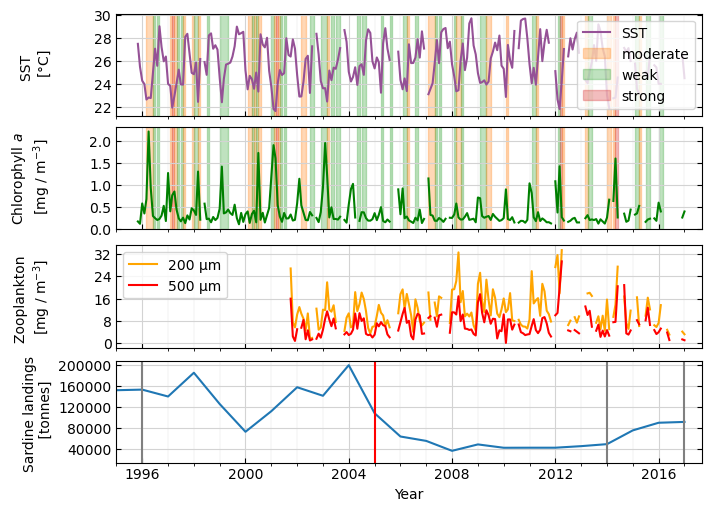

In [75]:
from matplotlib.ticker import MaxNLocator

plt.rcParams['figure.figsize'] = [7, 5]
f, ax = plt.subplots(4, 1, sharex='col', constrained_layout=True)  

color_dict={'SST':'#955196','P':'green','Z1':'orange','Z2':'red'}

ax[0].plot(CARIACO.date, CARIACO.SST, color=color_dict['SST'], label='SST')
ax[0].set_ylabel("SST \n"+r" [$\degree \mathrm{C}$]")

plot_state_as_color(x_data=CARIACO.date, state_data=CARIACO.ui, axis=ax[0])

ax[1].plot(CARIACO.date, CARIACO.Chlorophyll, color=color_dict['P'], label='Chlorophyll')
ax[1].set_ylabel("Chlorophyll $a$ \n"+r" [mg / $ \mathrm{m^{-3}}$]")

plot_state_as_color(x_data=CARIACO.date, state_data=CARIACO.ui, axis=ax[1])

ax[2].plot(CARIACO.date, CARIACO.Mesh200, color=color_dict['Z1'], label='200 µm')
ax[2].plot(CARIACO.date, CARIACO.Mesh500, color=color_dict['Z2'], label='500 µm')
ax[2].set_ylabel("Zooplankton \n"+r"[mg / $ \mathrm{ m^{-3} }$]")

ax[3].plot(Fish.date, Fish.sardinelandings)
ax[3].set_ylabel("Sardine landings \n"+r" [tonnes]")
ax[3].axvline(datetime.date(2005, 1, 1), color="red")
ax[3].axvline(datetime.date(1996, 1, 1), color="grey")
ax[3].axvline(datetime.date(2014, 1, 1), color="grey")
ax[3].axvline(datetime.date(2017, 1, 1), color="grey")



for i in range(4):
    ax[i].grid(True, color='lightgrey')
    ax[i].grid(True, lw=0.2, color='lightgrey', which="minor")
    ax[i].get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax[i].get_xaxis().set_minor_locator(mdates.YearLocator())
    ax[i].tick_params(top=False, right=True, direction="in")

plt.setp((ax,),xlim=(datetime.date(1995, 1, 1), datetime.date(2017, 9, 1)))
# Setting the limits for all axes.
#plt.setp((ax,), ylim=(0,2.5)) #, xlim=(-1, 100)

# format labels
f.align_ylabels()

ax[0].set_xlabel('')
ax[3].set_xlabel('Year')

# show legend
# show legend
ax[0].legend()
ax[2].legend()



# OK, now I have an overview over the time series
## what I need next is a plot of all metrics for during upwelling and during 
## relaxation, so a bunch of boxplots

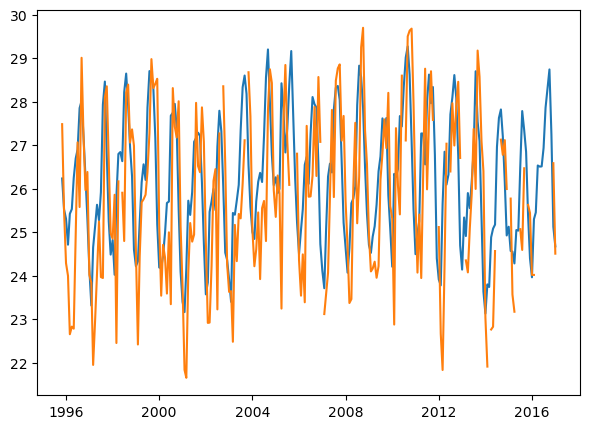

In [56]:
plt.plot(CARIACO.date,CARIACO.sst-273.15)
plt.plot(CARIACO.date,CARIACO.SST)

In [70]:
CARIACO.date

0     1995-11-01
1     1995-12-01
2     1996-01-01
3     1996-02-01
4     1996-03-01
         ...    
250   2016-09-01
251   2016-10-01
252   2016-11-01
253   2016-12-01
254   2017-01-01
Name: date, Length: 255, dtype: datetime64[ns]

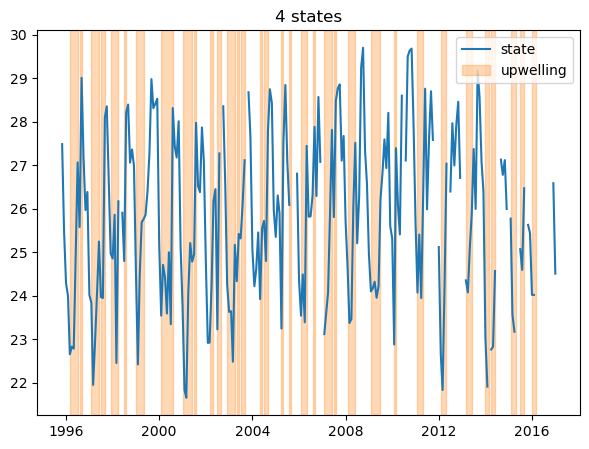

In [45]:
def plot_state_as_color(x_data, state_data, axis, add_labels=True):
    state_current = state_data[0]
    span_left = x_data[0]
    state_encountered = []
    for span_right, state_next in zip(x_data, state_data):
        if state_current != state_next:
            label = None
            if state_current not in state_encountered:
                state_encountered.append(state_current)
                if add_labels:
                    label = state_current
            if state_current == "upwelling":
                # plot section
                color = "C{}".format(state_encountered.index(state_current))
                axis.axvspan(span_left, span_right, color=color, alpha=0.3, label=label)
        
            # Update current state parameters
            span_left = span_right
            state_current = state_next

# Generate some data for the example
x_values = np.linspace(0, 10, 1000)
y_values = np.abs(np.sin(x_values))
state = [round(3*v) for v in y_values]

# figure with 4 states
plt.figure()
ax = plt.gca()
plt.plot(CARIACO.date, CARIACO.SST, label="state")
plot_state_as_color(x_data=CARIACO.date, state_data=CARIACO.justup, axis=ax)
plt.title("4 states")
plt.legend()

In [42]:
CARIACO['justup'] = CARIACO.upwelling
CARIACO.loc[CARIACO.upwelling!="upwelling", "justup"] = np.nan
CARIACO.justup

0            NaN
1            NaN
2            NaN
3            NaN
4      upwelling
         ...    
250          NaN
251          NaN
252          NaN
253          NaN
254          NaN
Name: justup, Length: 255, dtype: object

# OLD PLOT CODE AS INSPO:

In [ ]:
from matplotlib.ticker import MaxNLocator

color_dict={'N':'#955196','P':'green'}

plt.rcParams['figure.figsize'] = [5, 5]

f, ax = plt.subplots(2, 1, sharex='col', constrained_layout=True)  

for data, i, title in zip((chemostat_out, chemostat_out_sinu), (0,1), ('Sinusoidal forcing', 'Constant forcing')):
    # plot data + add labels
    data.Phytoplankton__value.plot(ax=ax[i], label='P', color=color_dict['P'])
    data.Nutrient__value.plot(ax=ax[i], label='N', color=color_dict['N'])
    ax[i].set_ylabel("["+chemostat_out_sinu.Phytoplankton__value.attrs['units']+"]")
    ax[i].set_title(title)

    # format plots
    ax[i].grid(True, color='lightgrey')
    ax[i].get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax[i].tick_params(top=False, right=True, direction="in")


# Setting the limits for all axes.
plt.setp((ax,), xlim=(-1, 100), ylim=(0,1.5))

# format labels
f.align_ylabels()

ax[0].set_xlabel('')
ax[1].set_xlabel('Time [days]')

# show legend
ax[0].legend()

# add subplot labels
for i, label in enumerate(('(a)', '(b)')):
    ax[i].text(0.1, 1.15, label, transform=ax[i].transAxes,
      fontsize=16, fontweight='normal', va='top', ha='right')